In [1]:
import pandas as pd

skills = pd.read_csv("../Datasets/public_skills_data.csv")

print("Shape:", skills.shape)
skills.head()

Shape: (144352, 13)


,2024 National Employment Matrix title,2024 National Employment Matrix code,"Employment, 2024","Employment, 2034","Employment change, numeric, 2024–34","Employment change, percent, 2024–34",EP skills ID,EP skills title,EP skills score,O*NET-SOC code,O*NET Element ID,O*NET element name,O*NET data value
0,Chief executives,11-1011,309.4,322.7,13.3,4.3,1,Adaptability,4.2,11-1011.00,1.C.4.a,Self-Control,4.21
1,Chief executives,11-1011,309.4,322.7,13.3,4.3,1,Adaptability,4.2,11-1011.00,1.C.4.b,Stress Tolerance,4.43
2,Chief executives,11-1011,309.4,322.7,13.3,4.3,1,Adaptability,4.2,11-1011.00,1.C.4.c,Adaptability/Flexibility,4.35
3,Chief executives,11-1011,309.4,322.7,13.3,4.3,1,Adaptability,4.2,11-1011.00,2.A.2.b,Active Learning,3.75
4,Chief executives,11-1011,309.4,322.7,13.3,4.3,1,Adaptability,4.2,11-1011.00,4.A.2.b.3,Updating and Using Relevant Knowledge,4.31


In [4]:
# clean column names

skills.columns = (
    skills.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(",", "")
    .str.replace("–", "_"))

skills.columns = skills.columns.str.replace("*", "", regex=False)
skills.columns


Index(['2024_national_employment_matrix_title',
       '2024_national_employment_matrix_code', 'employment_2024',
       'employment_2034', 'employment_change_numeric_2024_34',
       'employment_change_percent_2024_34', 'ep_skills_id', 'ep_skills_title',
       'ep_skills_score', 'onet-soc_code', 'onet_element_id',
       'onet_element_name', 'onet_data_value'],
      dtype='object')

## Skill Assessment - employment & skills exploration

In this section, we explore how different skills relate to projected employment growth from 2024 to 2034. 
Each row representes an occupation-skill pair, and we analyze whether certain skills are more common in occupations with higher growth.

In [5]:
df = skills[[
    "2024_national_employment_matrix_title",
    "2024_national_employment_matrix_code",
    "employment_2024",
    "employment_2034",
    "employment_change_percent_2024_34",
    "onet_element_name",
    "onet_data_value"]].copy()

df.head()

,2024_national_employment_matrix_title,2024_national_employment_matrix_code,employment_2024,employment_2034,employment_change_percent_2024_34,onet_element_name,onet_data_value
0,Chief executives,11-1011,309.4,322.7,4.3,Self-Control,4.21
1,Chief executives,11-1011,309.4,322.7,4.3,Stress Tolerance,4.43
2,Chief executives,11-1011,309.4,322.7,4.3,Adaptability/Flexibility,4.35
3,Chief executives,11-1011,309.4,322.7,4.3,Active Learning,3.75
4,Chief executives,11-1011,309.4,322.7,4.3,Updating and Using Relevant Knowledge,4.31


In [6]:
df.dtypes

2024_national_employment_matrix_title     object
2024_national_employment_matrix_code      object
employment_2024                          float64
employment_2034                          float64
employment_change_percent_2024_34        float64
onet_element_name                         object
onet_data_value                          float64
dtype: object

In [7]:
# get one row per occupation 
# (since occupations repeat for each skill)

occ_growth = df[[
    "2024_national_employment_matrix_code",
    "employment_change_percent_2024_34"
]].drop_duplicates()

# Compute thresholds
high_threshold = occ_growth["employment_change_percent_2024_34"].quantile(0.8)
low_threshold = occ_growth["employment_change_percent_2024_34"].quantile(0.2)

high_threshold, low_threshold

(np.float64(5.8), np.float64(-2.479999999999998))

- occupations growing more than 5.8% -> top 20%
- occupations shrinking more than 2.5% -> bottom 20%

In [8]:
# create a growth category column
def categorize_growth(x):
    if x >= high_threshold:
        return "high"
    elif x <= low_threshold:
        return "low"
    else:
        return "mid"

occ_growth["growth_category"] = occ_growth[
    "employment_change_percent_2024_34"
].apply(categorize_growth)

occ_growth["growth_category"].value_counts()

growth_category
mid     496
high    169
low     167
Name: count, dtype: int64

- we have good split

In [9]:
df = df.merge(
    occ_growth[[
        "2024_national_employment_matrix_code",
        "growth_category"
    ]],
    on="2024_national_employment_matrix_code",
    how="left"
)

# now every occupation will have a growth_categ 
df.head()

,2024_national_employment_matrix_title,2024_national_employment_matrix_code,employment_2024,employment_2034,employment_change_percent_2024_34,onet_element_name,onet_data_value,growth_category
0,Chief executives,11-1011,309.4,322.7,4.3,Self-Control,4.21,mid
1,Chief executives,11-1011,309.4,322.7,4.3,Stress Tolerance,4.43,mid
2,Chief executives,11-1011,309.4,322.7,4.3,Adaptability/Flexibility,4.35,mid
3,Chief executives,11-1011,309.4,322.7,4.3,Active Learning,3.75,mid
4,Chief executives,11-1011,309.4,322.7,4.3,Updating and Using Relevant Knowledge,4.31,mid


In [10]:
# keep only high and low (we ignore mid for now)
df_hl = df[df["growth_category"].isin(["high", "low"])]

# compute average skill score by skill name and growth group
skill_comparison = (
    df_hl.groupby(["onet_element_name", "growth_category"])["onet_data_value"]
    .mean()
    .unstack()
)

skill_comparison.head()

growth_category,high,low
onet_element_name,,
Active Learning,3.223879,2.701900
Active Listening,3.718645,3.214072
Adaptability/Flexibility,4.100280,3.807783
Analytical Thinking,3.940140,3.559457
Analyzing Data or Information,3.479720,2.993846


In [12]:
# we quantify this difference

skill_comparison["difference_high_minus_low"] = (
    skill_comparison["high"] - skill_comparison["low"]
)

# sort by largest positive difference
skill_comparison_sorted = skill_comparison.sort_values(
    "difference_high_minus_low",
    ascending=False
)

skill_comparison_sorted.head(10)


growth_category,high,low,difference_high_minus_low
onet_element_name,,,
E-Mail,4.116075,3.137557,0.978518
Performing for or Working Directly with the Public,3.082664,2.371674,0.710989
Biology,2.002056,1.329910,0.672147
Assisting and Caring for Others,3.221589,2.566697,0.654892
Science,2.092290,1.444208,0.648082
Customer and Personal Service,3.684019,3.036833,0.647186
Deal With External Customers or the Public in General,3.496636,2.850633,0.646002
Service Orientation,3.149252,2.552308,0.596945
Systems Evaluation,2.812991,2.239548,0.573443


_difference_hig_minus_low_ tells us how much important a skill is in high-growth jobs compared to low-growth jobs
- for example, e-mail -> 0.98 : high-growth jobs value email communication almost 1 point higher than low-growth jobs.
- biology -> 0.67 and science -> 0.65 : STEM-oriented skills are more concentrated in growing occupations.

Fast-growing jobs tend to emphasize:
- Communication
- Science/biology knowledge
- Systems thinking
- Service interaction
- Writing

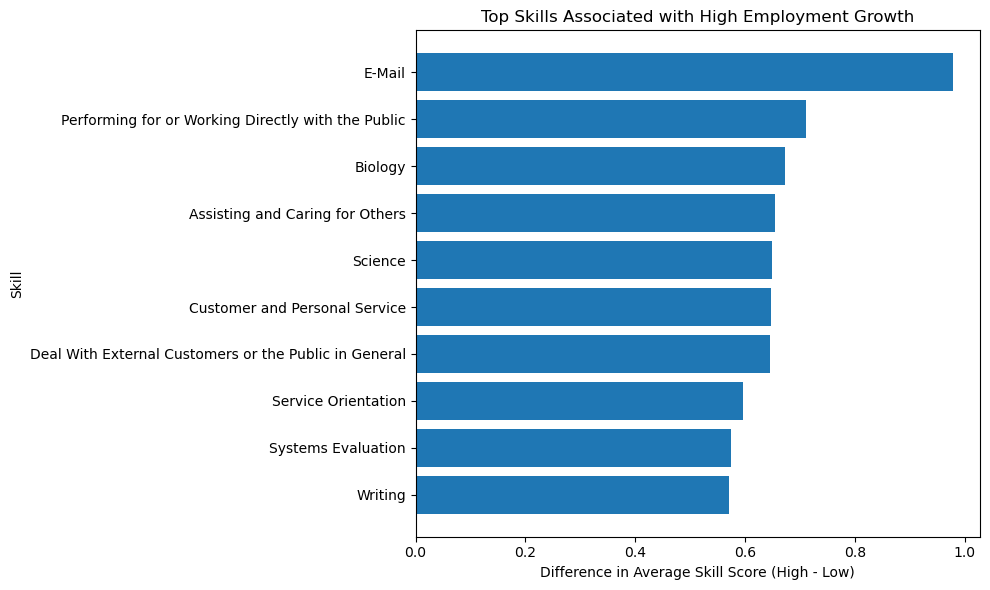

In [13]:
import matplotlib.pyplot as plt

top10 = skill_comparison_sorted.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10.index[::-1], top10["difference_high_minus_low"][::-1])

plt.title("Top Skills Associated with High Employment Growth")
plt.xlabel("Difference in Average Skill Score (High - Low)")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

In [14]:
# we find skills associated with decline

# sort ascending to get negative differences
bottom10 = skill_comparison.sort_values(
    "difference_high_minus_low",
    ascending=True
).head(10)

bottom10

growth_category,high,low,difference_high_minus_low
onet_element_name,,,
Controlling Machines and Processes,2.537150,3.261629,-0.724479
"Spend Time Using Your Hands to Handle, Control, or Feel Objects, Tools, or Controls",3.161215,3.848326,-0.687111
Control Precision,2.207850,2.860543,-0.652693
Operation and Control,2.017617,2.569683,-0.552066
Repairing and Maintaining Mechanical Equipment,2.040935,2.573077,-0.532142
Mechanical,2.140794,2.644570,-0.503776
Equipment Maintenance,1.583832,2.052534,-0.468702
Repairing,1.549673,1.994344,-0.444671
Multilimb Coordination,2.177944,2.573348,-0.395404


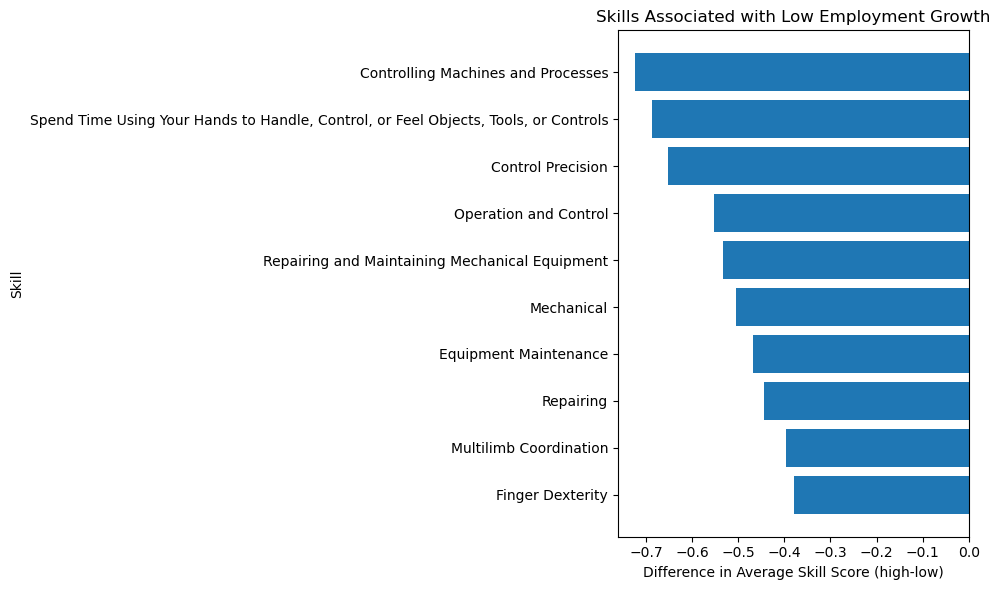

In [16]:
plt.figure(figsize=(10, 6))
plt.barh(bottom10.index[::-1], bottom10["difference_high_minus_low"][::-1])

plt.title("Skills Associated with Low Employment Growth")
plt.xlabel("Difference in Average Skill Score (high-low)")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

Skills more important in shrinking occupations include:
- Controlling machines and processes
- Manual handling of tools
- Mechanical
- Equipment maintenance
- Repairing
- Finger dexterity
- Multilimb coordination

### Pivot skills to occupation-level matrix

Instead of:
- occupation A - skill 1
- occupation A - skill 2
- occupation A - skill 3

We will have:
- Occupation A | Skill1 | Skill2 | Skill3 | ..


In [19]:
# create pivot table: rows = occupation, columns = skill, values = skill score
pivot_df = df.pivot_table(
    index="2024_national_employment_matrix_code",
    columns="onet_element_name",
    values="onet_data_value",
    aggfunc="mean"
)

pivot_df.head()


onet_element_name,Active Learning,Active Listening,Adaptability/Flexibility,Analytical Thinking,Analyzing Data or Information,Assisting and Caring for Others,Attention to Detail,Biology,Chemistry,Coaching and Developing Others,...,Training and Teaching Others,Troubleshooting,Trunk Strength,Updating and Using Relevant Knowledge,Work Outcomes and Results of Other Workers,Working with Computers,Wrist-Finger Speed,Writing,Written Comprehension,Written Expression
2024_national_employment_matrix_code,,,,,,,,,,,,,,,,,,,,,
11-1011,3.75,4.00,4.35,4.70,4.38,3.31,4.44,1.74,1.69,4.71,...,4.01,1.50,1.38,4.31,4.70,4.17,1.38,4.12,4.25,4.12
11-1021,3.62,4.00,4.35,4.17,4.04,3.02,4.74,1.21,1.91,3.91,...,3.41,1.75,2.12,3.80,4.33,4.46,1.75,3.50,4.00,4.00
11-1031,3.75,4.00,4.35,4.70,4.38,3.31,4.44,1.74,1.69,4.71,...,4.01,1.50,1.38,4.31,4.70,4.17,1.38,4.12,4.25,4.12
11-2011,3.25,4.12,4.42,3.88,3.26,2.37,4.48,1.23,1.22,2.62,...,2.74,1.00,1.62,3.78,3.80,4.61,1.75,3.75,4.00,3.88
11-2021,3.88,3.88,4.31,4.00,3.75,2.44,4.32,1.10,1.21,3.36,...,3.14,1.00,1.75,3.83,4.04,4.40,1.62,3.25,4.00,3.88


In [21]:
# create occupation-level growth df
occ_growth_clean = df[[
    "2024_national_employment_matrix_code",
    "employment_change_percent_2024_34"
]].drop_duplicates()

# merge growth into pivot table
reg_df = pivot_df.merge(
    occ_growth_clean,
    left_index=True,
    right_on="2024_national_employment_matrix_code",
    how="inner"
)

print(reg_df.head)
print(reg_df.shape)

<bound method NDFrame.head of         Active Learning  Active Listening  Adaptability/Flexibility  \
0              3.750000          4.000000                     4.350   
104            3.620000          4.000000                     4.350   
208            3.750000          4.000000                     4.350   
312            3.250000          4.120000                     4.420   
416            3.880000          3.880000                     4.310   
...                 ...               ...                       ...   
142376         2.880000          3.120000                     2.980   
142480         2.380000          2.880000                     3.890   
142584         2.250000          2.880000                     3.090   
142688         2.750000          3.000000                     3.940   
142792         2.451333          2.967333                     3.576   

        Analytical Thinking  Analyzing Data or Information  \
0                     4.700                           4

### Run a Simple Linear Regression (all skills)

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# define X (skills) and y (growth)
X = reg_df.drop(columns=[
    "2024_national_employment_matrix_code",
    "employment_change_percent_2024_34"
])

y = reg_df["employment_change_percent_2024_34"]

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# fit model
model = LinearRegression()
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)

r2

0.16431449752390592

- skills explain about 16.4% of the variation in prjected employment growth 

### Find top skills positively associated with growth.

In [23]:
import pandas as pd

coefficients = pd.Series(model.coef_, index=X.columns)

# Sort descending
coefficients_sorted = coefficients.sort_values(ascending=False)

coefficients_sorted.head(10)

Systems Evaluation                                3.750783
Deductive Reasoning                               2.958222
Oral Comprehension                                2.892431
Written Expression                                2.671614
Reading Comprehension                             2.622660
Multilimb Coordination                            2.606203
Active Learning                                   2.587621
Active Listening                                  2.417017
Customer and Personal Service                     2.194854
Coordinating the Work and Activities of Others    1.682489
dtype: float64

Top skill coeff = 3.75

Occupations that score higher in systems evaluation tend to have significantly higher projected employment growth, even after accounting for all other skills.


That makes sense for:
- AI
- Engineering
- Tech
- Data roles

In [24]:
coefficients_sorted.tail(10)


Wrist-Finger Speed                      -1.824239
Critical Thinking                       -1.876235
Monitoring and Controlling Resources    -1.997966
Training and Teaching Others            -2.024175
Importance of Being Exact or Accurate   -2.114312
Controlling Machines and Processes      -2.169478
Static Strength                         -2.264007
Selective Attention                     -3.779252
Speech Recognition                      -3.938575
Written Comprehension                   -4.422421
dtype: float64

### Ridge Regression

In [26]:
from sklearn.preprocessing import StandardScaler

# standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# train/test split again with scaled data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [27]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

r2_ridge = r2_score(y_test, y_pred_ridge)

r2_ridge


0.16968376743530877

In [28]:
ridge_coefficients = pd.Series(
    ridge_model.coef_,
    index=X.columns
)

ridge_sorted = ridge_coefficients.sort_values(ascending=False)

ridge_sorted.head(10)

Multilimb Coordination                                                                 2.286459
Systems Evaluation                                                                     1.968850
Customer and Personal Service                                                          1.689562
Written Expression                                                                     1.630008
Reading Comprehension                                                                  1.379907
Active Learning                                                                        1.341946
Deductive Reasoning                                                                    1.299422
Spend Time Using Your Hands to Handle, Control, or Feel Objects, Tools, or Controls    1.266913
Troubleshooting                                                                        1.209448
Oral Comprehension                                                                     1.188997
dtype: float64

In [29]:
ridge_sorted.tail(10)

Importance of Being Exact or Accurate             -0.907530
Guiding, Directing, and Motivating Subordinates   -0.944376
Monitoring and Controlling Resources              -1.128214
Training and Teaching Others                      -1.185800
Working with Computers                            -1.302656
Physics                                           -1.311837
Speech Recognition                                -1.430202
Static Strength                                   -1.768869
Controlling Machines and Processes                -2.034177
Written Comprehension                             -2.458835
dtype: float64

## Interpretation of Ridge Regression Results

Using Ridge regression, we find that employment growth is positively associated with analytical, cognitive, and communication-oriented skills such as Systems Evaluation, Deductive Reasoning, Active Learning, and Written/Oral Expression. 

In contrast, skills related to routine mechanical tasks and physical strength, such as Controlling Machines and Processes and Static Strength, are negatively associated with projected employment growth.

Overall, the results suggest a structural shift in the labor market toward knowledge-based, problem-solving, and communication-intensive occupations, while routine mechanical roles show weaker projected growth.


### Let's check for residuals on the Ridge model

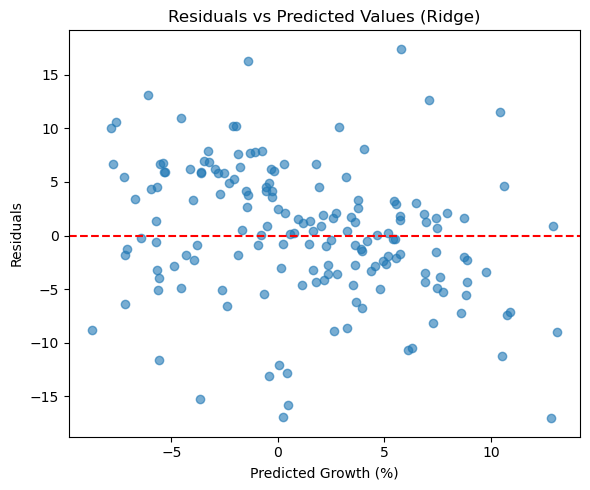

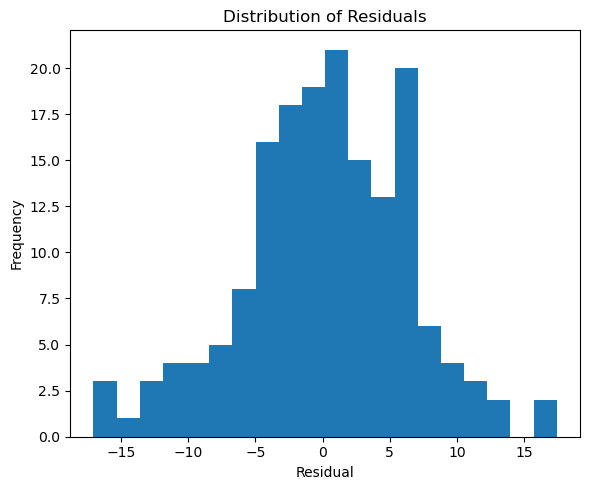

In [31]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_ridge

plt.figure(figsize=(6, 5))
plt.scatter(y_pred_ridge, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Growth (%)")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values (Ridge)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.hist(residuals, bins=20)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Model Diagnostics

Residual analysis suggests that the linearity assumption is reasonably satisfied, as residuals appear randomly distributed around zero without a clear pattern. The distribution of residuals is approximately symmetric, with no severe skewness. 

While some heteroscedasticity and tail behavior may exist, the assumptions of linear modeling are sufficiently satisfied for exploratory labor market analysis. Ridge regularization further mitigates multicollinearity among skill variables.


### We move to classification

Our goal is to predict:
- Is an occupation high-growth (1) or low-growth (0)?

In [32]:
# keep only high and low occupations
occ_high_low = occ_growth[
    occ_growth["growth_category"].isin(["high", "low"])
]

# merge with pivot_df
class_df = pivot_df.merge(
    occ_high_low[[
        "2024_national_employment_matrix_code",
        "growth_category"
    ]],
    left_index=True,
    right_on="2024_national_employment_matrix_code",
    how="inner"
)

# binary target: high = 1, low = 0
class_df["growth_binary"] = (
    class_df["growth_category"] == "high"
).astype(int)

class_df["growth_binary"].value_counts()


growth_binary
1    169
0    167
Name: count, dtype: int64

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# features (skills only)
X_class = class_df.drop(columns=[
    "2024_national_employment_matrix_code",
    "growth_category",
    "growth_binary"
])

# target
y_class = class_df["growth_binary"]

scaler_class = StandardScaler()
X_class_scaled = scaler_class.fit_transform(X_class)

# train/test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class_scaled,
    y_class,
    test_size=0.2,
    random_state=42)


# train logistic regression
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_c, y_train_c)

y_pred_c = log_model.predict(X_test_c)

accuracy = accuracy_score(y_test_c, y_pred_c)
accuracy

0.75

In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_c, y_pred_c)
cm

array([[24,  6],
       [11, 27]])

The logistic regression model achieves 75% accuracy in  high-growth from low-growth occupations using only skill profiles. The confusion matrix shows that the model correctly classifies most occupations in both categories, with slightly better performance in  identifying high-growth roles. Overall, skills contain meaningful predictive information about structural employment trends.


In [38]:
# extract logistic regression coeff
log_coefficients = pd.Series(
    log_model.coef_[0],
    index=X_class.columns
)

log_sorted = log_coefficients.sort_values(ascending=False)

log_sorted.head(10)


Multilimb Coordination                                  1.145743
Active Learning                                         0.951562
Assisting and Caring for Others                         0.930060
Fine Arts                                               0.810057
Equipment Selection                                     0.717296
Management of Personnel Resources                       0.698916
Repairing and Maintaining Mechanical Equipment          0.695096
Customer and Personal Service                           0.686638
Impact of Decisions on Co-workers or Company Results    0.675484
Service Orientation                                     0.662962
dtype: float64

In [39]:
log_sorted.tail(10)

Management of Financial Resources             -0.612513
Static Strength                               -0.717504
Training and Teaching Others                  -0.718500
Repairing                                     -0.868160
Self-Control                                  -0.871477
Organizing, Planning, and Prioritizing Work   -0.932128
Selective Attention                           -0.969344
Controlling Machines and Processes            -0.988365
Social Perceptiveness                         -0.999134
E-Mail                                        -1.017442
dtype: float64

## Model Comparison and Summary

Across both regression and classification approaches, skill structure shows a consistent relationship with projected employment growth.

The Ridge regression explains approximately 17% of the variation in employment growth, suggesting that skill composition plays a meaningful,though not exclusive, role in shaping occupational trends.

The logistic regression achieves 75% accuracy in distinguishing high-growth from low-growth occupations, indicating that skill profiles contain strong predictive signals regarding structural labor market shifts.

Together, these results suggest that growth occupations are increasingly characterized by analytical and service-oriented skills, while declining occupations rely more heavily on routine mechanical and strength-based tasks.


## Skill structure - PCA

In [41]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Use full occupation-level skill matrix (pivot_df)
X_pca = pivot_df.copy()

scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(X_pca)

# keep 2 components just for visualization
pca = PCA(n_components=2)
X_pca_components = pca.fit_transform(X_pca_scaled)

pca.explained_variance_ratio_

array([0.38676359, 0.12551079])

The first two components explain a bit over half of the total skill variation across occupations. But what do these components represent?

In [42]:
pca_df = pd.DataFrame(
    X_pca_components,
    columns=["PC1", "PC2"],
    index=pivot_df.index
)

pca_df.head()

,PC1,PC2
2024_national_employment_matrix_code,,
11-1011,13.418359,5.227198
11-1021,7.816487,2.462517
11-1031,13.418359,5.227198
11-2011,7.940718,-2.537017
11-2021,9.066929,-0.643338


In [43]:
pca_df = pca_df.merge(
    occ_growth[[
        "2024_national_employment_matrix_code",
        "growth_category"
    ]],
    left_index=True,
    right_on="2024_national_employment_matrix_code",
    how="left"
)

pca_df.head()

,PC1,PC2,2024_national_employment_matrix_code,growth_category
0,13.418359,5.227198,11-1011,mid
104,7.816487,2.462517,11-1021,mid
208,13.418359,5.227198,11-1031,mid
312,7.940718,-2.537017,11-2011,mid
416,9.066929,-0.643338,11-2021,high


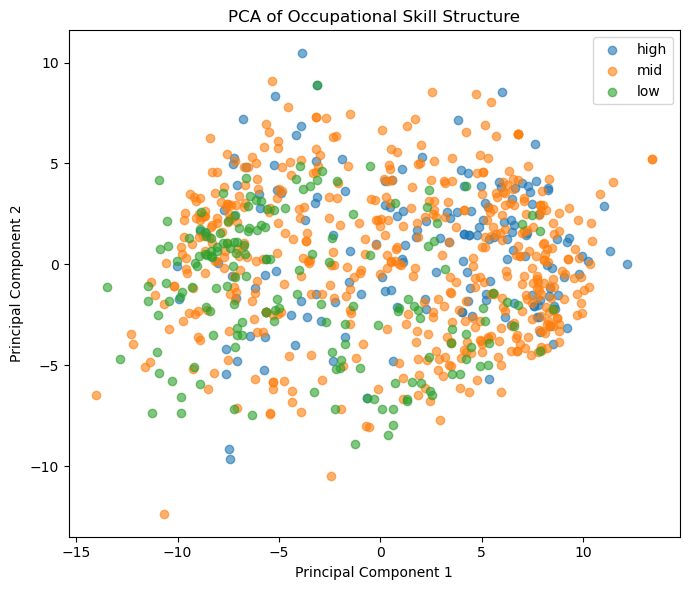

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

for category in ["high", "mid", "low"]:
    subset = pca_df[pca_df["growth_category"] == category]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=category,
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Occupational Skill Structure")
plt.legend()
plt.tight_layout()
plt.show()


In [45]:
# get loadings (importance of each skill in PC1 and PC2)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=pivot_df.columns
)

# sort by absolute contribution to PC1
pc1_sorted = loadings["PC1"].sort_values(ascending=False)

pc1_sorted.head(10)

onet_element_name
Written Expression       0.146016
Active Listening         0.144085
Writing                  0.144038
Reading Comprehension    0.143891
Written Comprehension    0.143287
Speaking                 0.142975
Oral Expression          0.142218
Oral Comprehension       0.139460
Speech Clarity           0.136296
Active Learning          0.135038
Name: PC1, dtype: float64

In [46]:
pc1_sorted.tail(10)

onet_element_name
Gross Body Coordination                                                               -0.113143
Stamina                                                                               -0.116503
Control Precision                                                                     -0.119924
Spend Time Bending or Twisting Your Body                                              -0.120638
Spend Time Using Your Hands to Handle, Control, or Feel Objects, Tools, or Controls   -0.120640
Dynamic Strength                                                                      -0.120920
Trunk Strength                                                                        -0.122377
Static Strength                                                                       -0.123298
Multilimb Coordination                                                                -0.125040
Extent Flexibility                                                                    -0.126096
Name: PC1, dtype: floa

Top Positive PC1 Skills:
- Written Expression
- Active Listening
- Writing
- Reading Comprehension
- Oral Expression
- Speech Clarity
- Active Learning

These are clearly:
- Cognitive
- Communication
- Literacy
- Knowledge-based skills

Top Negative PC1 Skills:
- Gross Body Coordination
- Static Strength
- Trunk Strength
- Dynamic Strength
- Control Precision
- Bending / Twisting Body
- Multilimb Coordination

These are clearly:
- Physical
- Manual
- Strength-based
- Mechanical


Now we test:
- Do high-growth occupations have higher PC1 values?

If yes:
- Growth is strongly associated with movement toward the cognitive end of the skill spectrum.

In [47]:
pca_df.groupby("growth_category")["PC1"].mean()

growth_category
high    1.813317
low    -3.715257
mid     0.633059
Name: PC1, dtype: float64

PC1 = Cognitive/Communication <-> Physical/Manual axis.
So:
- High-growth occupations sit clearly on the cognitive/communication side.
- Low-growth occupations sit strongly on the physical/manual side.
- And mid-growth sits in between.

### Interpretation of Principal Component 1

The first principal component (PC1) represents a clear cognitive–manual skill dimension. Occupations with high PC1 values emphasize communication, literacy, reasoning, and active learning skills, while occupations with low PC1 values emphasize physical strength, coordination, and manual tasks.

High-growth occupations exhibit substantially higher average PC1 values compared to low-growth occupations. This suggests that projected employment growth is strongly aligned with a shift toward cognitive and communication-intensive skill profiles.


In [48]:
from scipy.stats import ttest_ind

high_pc1 = pca_df[pca_df["growth_category"] == "high"]["PC1"]
low_pc1 = pca_df[pca_df["growth_category"] == "low"]["PC1"]

ttest_ind(high_pc1, low_pc1)

TtestResult(statistic=np.float64(9.134741233949972), pvalue=np.float64(6.458913496101289e-18), df=np.float64(334.0))

A two-sample t-test confirms that the difference in PC1 values between high- and low-growth occupations is highly statistically significant (p < 0.001). This provides strong evidence that projected employment growth is  aligned with the cognitive–manual skill dimension identified by PCA.


### Economic interpretation
“Each one-unit increase along the cognitive dimension is associated with X% higher employment growth.”

## Growth as a Function of the Cognitive Skill Dimension


In [49]:
import statsmodels.api as sm

# prepare data
pc1_reg_df = pca_df.dropna(subset=["PC1"])
pc1_reg_df = pc1_reg_df.merge(
    occ_growth[[
        "2024_national_employment_matrix_code",
        "employment_change_percent_2024_34"
    ]],
    on="2024_national_employment_matrix_code",
    how="left"
)

X_pc1 = sm.add_constant(pc1_reg_df["PC1"])
y_growth = pc1_reg_df["employment_change_percent_2024_34"]

model_pc1 = sm.OLS(y_growth, X_pc1).fit()

print(model_pc1.summary())


                                    OLS Regression Results                                   
Dep. Variable:     employment_change_percent_2024_34   R-squared:                       0.086
Model:                                           OLS   Adj. R-squared:                  0.085
Method:                                Least Squares   F-statistic:                     78.02
Date:                               Sun, 15 Feb 2026   Prob (F-statistic):           6.00e-18
Time:                                       19:48:36   Log-Likelihood:                -2833.3
No. Observations:                                832   AIC:                             5671.
Df Residuals:                                    830   BIC:                             5680.
Df Model:                                          1                                         
Covariance Type:                           nonrobust                                         
                 coef    std err          t      P>|t|      

Results summary:

- PC1 Coefficient: 0.354
- p-value: < 0.001 (essentially zero)
- R²: 0.086

**Magnitute**

A one-unit increase along the cognitive skill dimension (PC1) is associated with **0.35** percentage points higher projected employment growth

**Statistical Significance**

p-value is essentially 0 -> The relationship between the cognitive skill dimension and employment growth is not random.

**R^2 Interpretation**

PC1 alone explains about **8.6%** of variation in employment growth. This is strong fo a single composite dimension derived from 103 skills.

## Overall Conclusion

This project examined the relationship between occupational skill composition and projected employment growth from 2024 to 2034.

Across multiple analytical approaches, including descriptive comparison, Ridge regression, logistic classification, and Principal Component Analysis, a consistent structural pattern emerges. Occupations projected to experience higher growth are characterized by stronger cognitive, communication, analytical, and adaptive skill profiles. In contrast, occupations projected to decline rely more heavily on routine mechanical, strength-based, and manual coordination skills.

The first principal component of the skill space captures a clear cognitive–manual dimension, explaining nearly 39% of total skill variation. This dimension is strongly aligned with employment growth, with statistically significant differences between high- and low-growth occupations and a positive association with projected growth magnitude.

Together, these findings suggest that the future labor market is increasingly shaped by a shift toward knowledge-intensive, problem-solving, and communication-driven roles. While skill composition does not fully determine employment growth, it represents a meaningful force influencing occupational trajectories.
